# Clase 7: Etapas finales de la Evolución


## Objetivos
1. El Paradigma Roto: Múltiples Poblaciones en Cúmulos Globulares.
2. Astrometría de Precisión en la Era de Gaia.
3. Detección de Corrientes Estelares y Colas de Marea.



## 1. El Paradigma Roto: Múltiples Poblaciones en Cúmulos Globulares

Durante décadas, los cúmulos globulares (GCs) se consideraron Poblaciones Estelares Simples (SSP): estrellas coetáneas con idéntica metalicidad y abundancia química inicial. Hoy sabemos que casi todos los GCs masivos albergan **Múltiples Poblaciones (MPs)**.

El paradigma colapsó al observar correlaciones químicas anómalas (anti-correlación Na-O y C-N) que no pueden explicarse por nucleosíntesis *in situ* en estrellas de baja masa, y desdoblamientos en el Diagrama Color-Magnitud (CMD) en filtros sensibles al ultravioleta (UV).

### El Efecto del Helio en el Turn-Off

Las poblaciones de segunda generación (2G) suelen estar enriquecidas en Helio ($Y$). Un aumento en la fracción de masa de Helio ($\Delta Y$) disminuye la opacidad de Kramers en el interior estelar y aumenta el peso molecular medio ($\mu$), haciendo que la estrella sea más caliente y luminosa.

La luminosidad de una estrella en la secuencia principal escala como:

$$L \propto \mu^{7.5} M^{5.5} R^{-0.5}$$

Sabiendo que el peso molecular medio depende de las fracciones de masa de Hidrógeno ($X$), Helio ($Y$) y metales ($Z$):

$$\mu = \frac{4}{2X + \frac{3}{4}Y + \frac{1}{2}Z}$$

Si $Y$ aumenta (y $X$ disminuye, manteniendo $Z$ constante), $\mu$ aumenta dramáticamente. La edad del cúmulo evaluada en el *Turn-Off* ($t_{\text{TO}}$) obedece a la relación:

$$\frac{\Delta t_{\text{TO}}}{t_{\text{TO}}} \approx -1.3 \Delta Y$$

Esto demuestra que, a una misma edad real, una sub-población enriquecida en Helio aparecerá como si fuera significativamente más joven (o más azul) en el CMD, creando la falsa ilusión de dispersión de edades.

> **El "Chromosome Map"**
> El mapa cromosómico es un pseudo-CMD desarrollado por Milone et al. (2017) utilizando datos del telescopio espacial Hubble (HST). Al combinar filtros UV y ópticos ($\Delta_{F275W, F814W}$ vs $\Delta_{F275W, F336W, F438W}$), el CMD vertical se "estira" revelando racimos de estrellas distintos. Las estrellas de primera generación (1G) se agrupan en el origen, mientras que las 2G se extienden hacia colores que reflejan depleción de Oxígeno y enriquecimiento de Nitrógeno.

### Simulación Teórica de Múltiples Poblaciones (Pseudo-CMD)


<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_5924/2239389135.py:20: SyntaxWarning: invalid escape sequence '\D'
  plt.scatter(color_2g, mag_2g, s=5, c='red', alpha=0.6, label='2G (Enriquecida: Pobre en O, Rico en Na, $\Delta Y > 0$)')


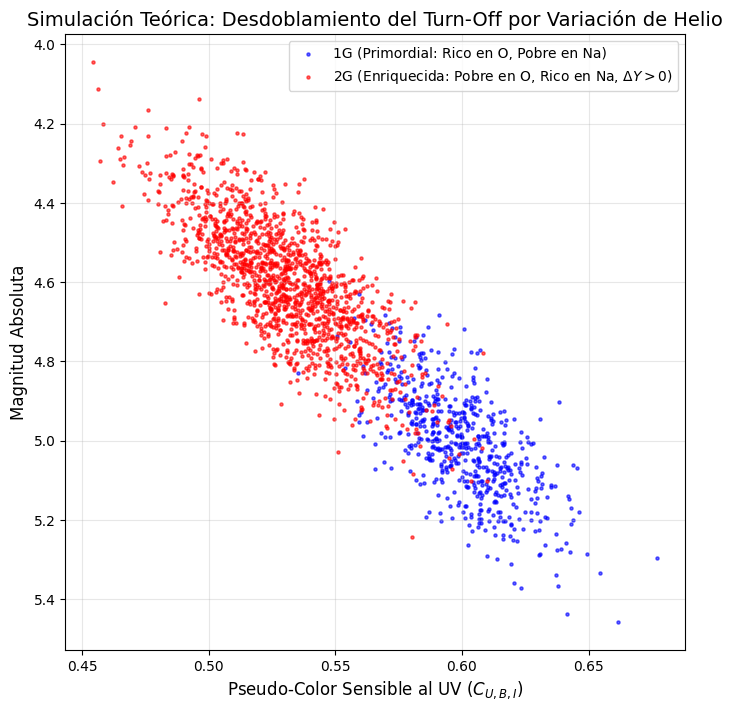

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Simulación de un cúmulo con dos poblaciones estelares (1G y 2G)
np.random.seed(42)
N_estrellas = 2000

# Población 1G (Composición primordial: Helio normal, Oxígeno alto)
N_1g = int(N_estrellas * 0.3)
color_1g = np.random.normal(0.6, 0.02, N_1g)
mag_1g = 5.0 * color_1g + np.random.normal(2.0, 0.1, N_1g)

# Población 2G (Composición alterada: Helio enriquecido, Oxígeno bajo -> más azul en UV)
N_2g = N_estrellas - N_1g
color_2g = np.random.normal(0.53, 0.025, N_2g) # Desplazamiento hacia el azul por del(Y)
mag_2g = 5.0 * color_2g + np.random.normal(1.95, 0.1, N_2g)

plt.figure(figsize=(8, 8))
plt.scatter(color_1g, mag_1g, s=5, c='blue', alpha=0.6, label='1G (Primordial: Rico en O, Pobre en Na)')
plt.scatter(color_2g, mag_2g, s=5, c='red', alpha=0.6, label='2G (Enriquecida: Pobre en O, Rico en Na, $\Delta Y > 0$)')
plt.gca().invert_yaxis()
plt.title("Simulación Teórica: Desdoblamiento del Turn-Off por Variación de Helio", fontsize=14)
plt.xlabel("Pseudo-Color Sensible al UV ($C_{U,B,I}$)", fontsize=12)
plt.ylabel("Magnitud Absoluta", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2. Astrometría de Precisión en la Era de Gaia

La misión Gaia mide los cinco parámetros astrométricos básicos ($\alpha, \delta, \varpi, \mu_\alpha^*, \mu_\delta$) con precisiones de micro-segundos de arco ($\mu$as). Sin embargo, explotar estos datos exige un tratamiento estadístico riguroso de la matriz de covarianza y la propagación de errores.

### Demostración Matemática: Velocidad Tangencial y Propagación de Errores

La velocidad tangencial $v_T$ (en km/s) se deriva del movimiento propio total $\mu = \sqrt{(\mu_\alpha^*)^2 + \mu_\delta^2}$ (en mas/año) y el paralaje $\varpi$ (en mas):

$$v_T = A \frac{\mu}{\varpi}$$

Donde $A = 4.74047$ es la constante de conversión astronómica (1 UA / 1 año en km/s).

Para calcular la incertidumbre $\sigma_{v_T}$, aplicamos la propagación de errores asumiendo correlaciones ($C_{\mu, \varpi}$):

$$\sigma_{v_T}^2 = \left( \frac{\partial v_T}{\partial \mu} \right)^2 \sigma_\mu^2 + \left( \frac{\partial v_T}{\partial \varpi} \right)^2 \sigma_\varpi^2 + 2 \left( \frac{\partial v_T}{\partial \mu} \right) \left( \frac{\partial v_T}{\partial \varpi} \right) C_{\mu, \varpi}$$

Calculando las derivadas parciales:

$$\frac{\partial v_T}{\partial \mu} = \frac{A}{\varpi}, \quad \frac{\partial v_T}{\partial \varpi} = -A \frac{\mu}{\varpi^2}$$

Sustituyendo:

$$\left( \frac{\sigma_{v_T}}{v_T} \right)^2 = \left( \frac{\sigma_\mu}{\mu} \right)^2 + \left( \frac{\sigma_\varpi}{\varpi} \right)^2 - 2 \frac{C_{\mu, \varpi}}{\mu \varpi}$$

> **RUWE y el Sesgo de Lutz-Kelker**
> 1. **RUWE (Renormalised Unit Weight Error):** Un valor RUWE $> 1.4$ en Gaia indica que el modelo astrométrico de fuente única falla. Suele revelar sistemas binarios no resueltos o ruido instrumental.
> 2. **Sesgo de Lutz-Kelker:** Invertir el paralaje ($d = 1/\varpi$) genera estimaciones de distancia sobreestimadas porque el volumen del espacio crece con $d^2$, haciendo que siempre haya más estrellas a distancias mayores cuyos errores las "empujen" estadísticamente hacia paralajes medidos más grandes.

### Extracción Astrométrica y Calidad en Gaia


<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5924/905732445.py:38: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_title('Distribución Cinemática (Campo del Halo, $b > 60^\circ$)', fontsize=14, fontweight='bold')
/tmp/ipykernel_5924/905732445.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('$\mu_{\\alpha*}$ (mas/año)', fontsize=12)
/tmp/ipykernel_5924/905732445.py:48: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$\mu_{\delta}$ (mas/año)', fontsize=12)


Descargando datos astrométricos de Gaia DR3 (Modo síncrono en tiempo real)...
Estrellas extraídas con RUWE < 1.2: 997
Velocidad Tangencial Promedio en el campo: 55.6 km/s


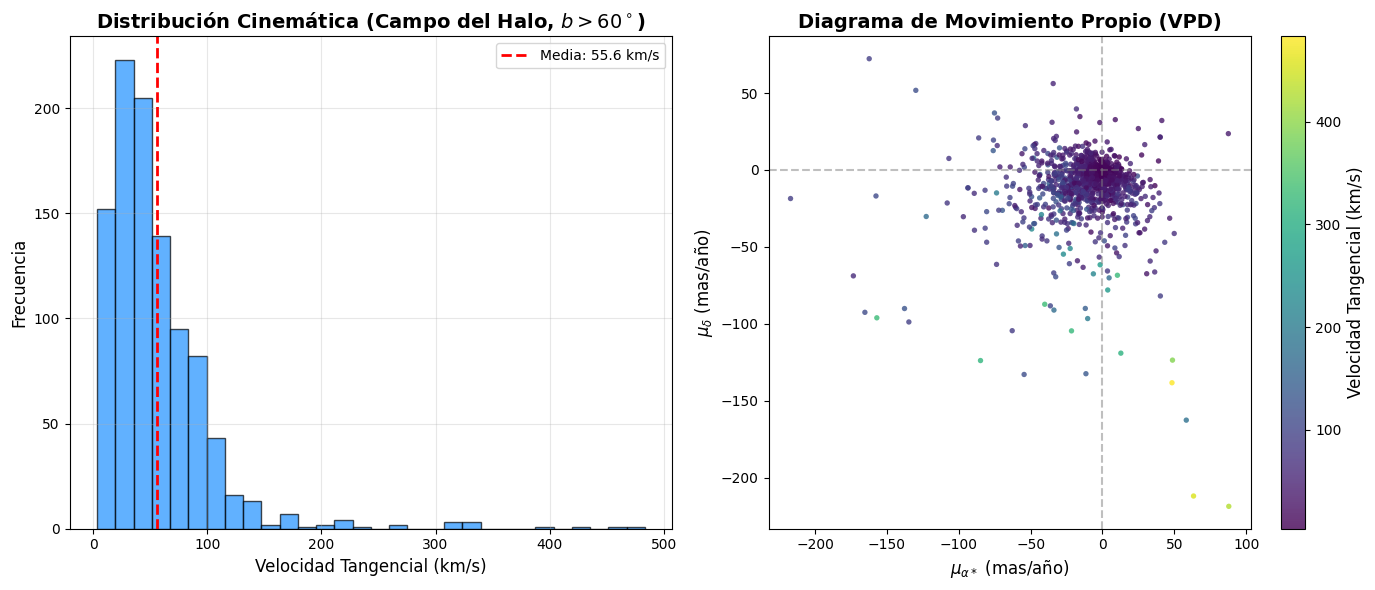

In [18]:
from astroquery.gaia import Gaia
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Consulta ADQL limpia para ejecución síncrona inmediata
query = """
SELECT TOP 1000 ra, dec, parallax, parallax_error, pmra, pmdec, pmra_error, pmdec_error, ruwe, phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE parallax > 1.0
  AND parallax_over_error > 10
  AND ruwe < 1.2
  AND b > 60
"""

print("Descargando datos astrométricos de Gaia DR3 (Modo síncrono en tiempo real)...")
# Ejecución síncrona: el script esperará la respuesta inmediata del servidor
job = Gaia.launch_job(query)
df_halo = job.get_results().to_pandas()

# Limpieza de nulos preventiva
df_halo = df_halo.dropna(subset=['pmra', 'pmdec', 'parallax', 'phot_g_mean_mag', 'bp_rp'])

# Cálculo de Velocidad Tangencial Clásica
mu = np.sqrt(df_halo['pmra']**2 + df_halo['pmdec']**2)
df_halo['v_tangencial_km_s'] = 4.74 * (mu / df_halo['parallax'])

print(f"Estrellas extraídas con RUWE < 1.2: {len(df_halo)}")
print(f"Velocidad Tangencial Promedio en el campo: {df_halo['v_tangencial_km_s'].mean():.1f} km/s")

# Visualización Gráfica Cinemática
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Histograma de Velocidades Tangenciales
ax1.hist(df_halo['v_tangencial_km_s'], bins=30, color='dodgerblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Velocidad Tangencial (km/s)', fontsize=12)
ax1.set_ylabel('Frecuencia', fontsize=12)
ax1.set_title('Distribución Cinemática (Campo del Halo, $b > 60^\circ$)', fontsize=14, fontweight='bold')
ax1.axvline(df_halo['v_tangencial_km_s'].mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Media: {df_halo["v_tangencial_km_s"].mean():.1f} km/s')
ax1.legend()
ax1.grid(alpha=0.3)

# Panel 2: Diagrama de Movimientos Propios (VPD)
scatter = ax2.scatter(df_halo['pmra'], df_halo['pmdec'], s=15, c=df_halo['v_tangencial_km_s'],
                      cmap='viridis', alpha=0.8, edgecolor='none')
ax2.set_xlabel('$\mu_{\\alpha*}$ (mas/año)', fontsize=12)
ax2.set_ylabel('$\mu_{\delta}$ (mas/año)', fontsize=12)
ax2.set_title('Diagrama de Movimiento Propio (VPD)', fontsize=14, fontweight='bold')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)

cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Velocidad Tangencial (km/s)', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Detección de Corrientes Estelares y Colas de Marea

Los cúmulos globulares y galaxias enanas que orbitan la Vía Láctea están sometidos al gradiente gravitacional (fuerza de marea) de la Galaxia. Cuando las estrellas cruzan la superficie equipotencial de Roche, escapan del cúmulo formando "colas de marea": una adelantada (leading) y otra atrasada (trailing).

### El Radio de Jacobi

El límite de influencia gravitacional de un cúmulo estelar de masa $m$ que orbita una galaxia anfitriona de masa $M_G$ a una distancia $R_G$ se define como el Radio de Jacobi ($r_J$).

Igualando la aceleración de marea ejercida por la Galaxia a la gravedad de autoligadura del cúmulo en un marco de referencia rotatorio:

$$G \frac{m}{r_J^2} = \Omega^2 r_J - \left. \frac{d^2 \Phi_G}{dR^2} \right|_{R_G} r_J$$

Para una galaxia masiva puntual, $\Omega^2 = GM_G/R_G^3$ y la derivada del potencial arroja un factor $2GM_G/R_G^3$. Resolviendo para $r_J$, obtenemos la aproximación clásica:

$$r_J \approx R_G \left( \frac{m}{3 M_G} \right)^{1/3}$$

Las estrellas que por interacciones dinámicas cruzan $r > r_J$ son extraídas cinemáticamente. Las estrellas expulsadas hacia el interior orbital ($< R_G$) ganan velocidad angular y forman la cola *adelantada*; las expulsadas hacia el exterior ($> R_G$) pierden velocidad angular y forman la cola *atrasada*.

### Simulación Computacional: Destrucción por Mareas (N-Body 2D)


Radio de Jacobi del sistema: 2.99


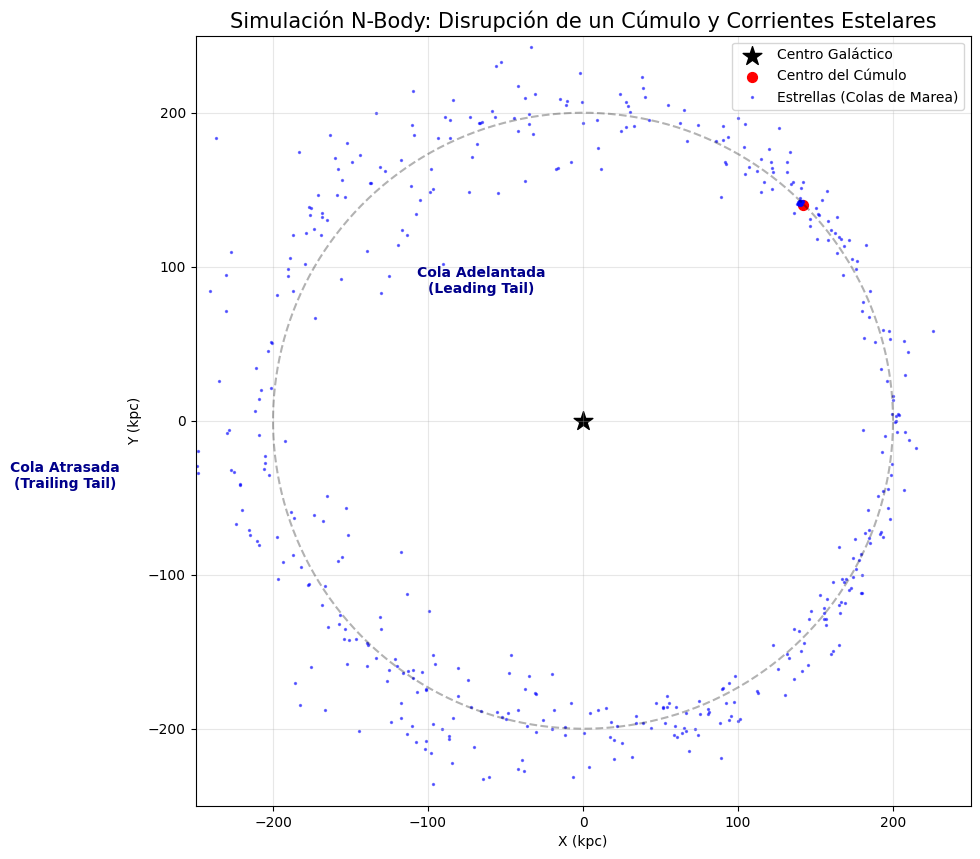

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos (Unidades arbitrarias: G=1)
G = 1.0
M_gal = 100000.0  # Masa de la Galaxia
M_clu = 1.0       # Masa del Cúmulo
R_orbit = 200.0   # Radio de la órbita del cúmulo

# Velocidad circular del cúmulo
V_clu = np.sqrt(G * M_gal / R_orbit)

# Inicialización de 500 partículas (Estrellas del cúmulo)
N_particles = 500
r_J = R_orbit * (M_clu / (3 * M_gal))**(1/3) # Radio de Jacobi Teórico
print(f"Radio de Jacobi del sistema: {r_J:.2f}")

# Distribución gaussiana de posiciones dentro del cúmulo
np.random.seed(101)
dx = np.random.normal(0, r_J*0.5, N_particles)
dy = np.random.normal(0, r_J*0.5, N_particles)
x = R_orbit + dx
y = 0.0 + dy

# Velocidades iniciales (Velocidad del cúmulo + dispersión aleatoria virializada)
v_dispersion = np.sqrt(G * M_clu / r_J) * 1.5
vx = 0.0 + np.random.normal(0, v_dispersion, N_particles)
vy = V_clu + np.random.normal(0, v_dispersion, N_particles)

# Parámetros de integración (Método de Euler Semi-Implícito / Leapfrog)
dt = 0.1
t_max = 850.0  # Suficiente para dar ~1 órbita y media
pasos = int(t_max / dt)

# Trayectoria del centro del cúmulo para referencia
x_c, y_c = R_orbit, 0.0
vx_c, vy_c = 0.0, V_clu

for step in range(pasos):
    # Fuerza sobre el centro del cúmulo (Solo Galaxia)
    r_c = np.sqrt(x_c**2 + y_c**2)
    ax_c = -G * M_gal * x_c / r_c**3
    ay_c = -G * M_gal * y_c / r_c**3

    vx_c += ax_c * dt
    vy_c += ay_c * dt
    x_c += vx_c * dt
    y_c += vy_c * dt

    # Fuerzas sobre las partículas (Galaxia + Cúmulo)
    r_gal = np.sqrt(x**2 + y**2)
    r_rel = np.sqrt((x - x_c)**2 + (y - y_c)**2)

    # Prevención de divergencia en r=0 (Softening)
    epsilon = 0.5

    ax = -G * M_gal * x / r_gal**3 - G * M_clu * (x - x_c) / (r_rel**3 + epsilon**3)
    ay = -G * M_gal * y / r_gal**3 - G * M_clu * (y - y_c) / (r_rel**3 + epsilon**3)

    vx += ax * dt
    vy += ay * dt
    x += vx * dt
    y += vy * dt

# Gráfica del resultado final
plt.figure(figsize=(10, 10))
plt.scatter(0, 0, color='black', s=200, marker='*', label='Centro Galáctico')
plt.scatter(x_c, y_c, color='red', s=50, label='Centro del Cúmulo')
plt.scatter(x, y, color='blue', s=2, alpha=0.5, label='Estrellas (Colas de Marea)')

# Dibujar la órbita teórica del cúmulo
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(R_orbit * np.cos(theta), R_orbit * np.sin(theta), 'k--', alpha=0.3)

# Identificación física de las colas en la gráfica
r_final = np.sqrt(x**2 + y**2)
plt.text(x[np.argmin(r_final)], y[np.argmin(r_final)]-15, "Cola Adelantada\n(Leading Tail)", color='darkblue', fontweight='bold', ha='center')
plt.text(x[np.argmax(r_final)], y[np.argmax(r_final)]+15, "Cola Atrasada\n(Trailing Tail)", color='darkblue', fontweight='bold', ha='center')

plt.xlim(-250, 250)
plt.ylim(-250, 250)
plt.title("Simulación N-Body: Disrupción de un Cúmulo y Corrientes Estelares", fontsize=15)
plt.xlabel("X (kpc)")
plt.ylabel("Y (kpc)")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

In [20]:
## Escriba aquí su solución